<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
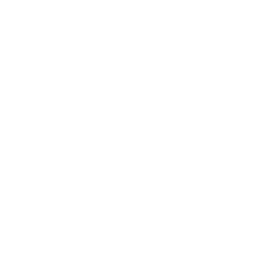
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering van Energie-efficiëntie van Gebouwen</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energie / Duurzaamheidsanalyse &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Samenvatting

Dit uitgewerkte voorbeeld clustert een portefeuille van commerciële gebouwen aan de hand van vijf energie-efficiëntiematen — energiegebruiksintensiteit (EUI), HVAC-efficiëntieratio, thermische weerstand van het gebouwomhulsel, verlichtingsvermogendichtheid en aandeel hernieuwbare energie — om onderscheidende prestatieniveaus in kaart te brengen voor het richten van energiesubsidies. De analyse gebruikt **PROC FASTCLUS** met `REPLACE=FULL` (volledige vervanging van startpunten) en vergelijkt de oplossingen voor k=3, 4, 5 en 6 op de totale R-kwadraat, de pseudo-F-statistiek en de minimale clustergrootte. De k=4-oplossing wordt vervolgens in detail geprofileerd en elk cluster wordt gekoppeld aan een uitvoerbaar efficiëntieniveau. Omdat deze omgeving ongelicentieerd draait, is de demonstratie beperkt tot een steekproef van 100 gebouwen; hetzelfde programma schaalt ongewijzigd op naar een volledige portefeuille.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Jaarlijkse energie-efficiëntiematen per gebouw (synthetisch) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Genereer synthetische gebouwenergiegegevens
   Efficiëntie-indicatoren voor commerciële gebouwen
   -------------------------------------------------------- */
GEGEVENS work.building_metrics;
    CALL streaminit(42);
    REEKS btypes[5] $15 _temporary_ ('KANTOOR' 'WINKEL' 'MAGAZIJN' 'ZIEKENHUIS' 'SCHOOL');
    REEKS regions[4] $12 _temporary_ ('NOORDOOST' 'ZUIDOOST' 'MIDWESTEN' 'WEST');
    label
        building_id       = "Gebouw-ID"
        building_type     = "Gebouwtype"
        climate_region    = "Klimaatregio"
        eui               = "Energiegebruiksintensiteit (kBtu/sqft/jr)"
        hvac_efficiency   = "HVAC-efficiëntie (COP)"
        envelope_r_value  = "Thermische weerstand omhulsel (R-waarde)"
        lighting_wpf      = "Verlichtingsvermogendichtheid (W/sqft)"
        renewable_pct     = "Aandeel hernieuwbare energie (%)"
        building_age      = "Gebouwleeftijd (jaar)"
        floor_area_ksf    = "Vloeroppervlak (duizend sqft)";
    DOE building_id = 1 TOT 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Energiegebruiksintensiteit (kBtu/sqft/jr) */
        eui = round(rand('normal', 85, 35), 0.1);
        ALS eui < 15 DAN eui = 15;
        ALS eui > 250 DAN eui = 250;

        /* HVAC-efficiëntieratio (COP-equivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        ALS hvac_efficiency < 1.0 DAN hvac_efficiency = 1.0;
        ALS hvac_efficiency > 6.0 DAN hvac_efficiency = 6.0;

        /* Thermische weerstand omhulsel (R-waarde) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        ALS envelope_r_value < 5 DAN envelope_r_value = 5;
        ALS envelope_r_value > 40 DAN envelope_r_value = 40;

        /* Verlichtingsvermogendichtheid (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        ALS lighting_wpf < 0.3 DAN lighting_wpf = 0.3;
        ALS lighting_wpf > 2.5 DAN lighting_wpf = 2.5;

        /* Aandeel hernieuwbare energie */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        ALS renewable_pct > 80 DAN renewable_pct = 80;

        /* Leeftijd van het gebouw in jaren */
        building_age = int(rand('uniform') * 80) + 1;

        /* Vloeroppervlak (duizenden sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        ALS floor_area_ksf > 500 DAN floor_area_ksf = 500;

        UITVOER;
    EINDE;
    VERWIJDEREN type_idx reg_idx;
UITVOEREN;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.59 seconds
  cpu   1.59 seconds


---

In [2]:
/* --------------------------------------------------------
   Basisverdeling van energiematen per gebouwtype
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.building_metrics n mean std;
    KLASSE building_type;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Energiematen per Gebouwtype";
UITVOEREN;


                                              Energiematen per Gebouwtype                                               

                                                  The MEANS Procedure

                           Analysis Variable : eui Energiegebruiksintensiteit (kBtu/sqft/jr)

        Gebouwtype          N Obs           Mean        Std Dev
        -------------------------------------------------------
        KANTOOR                20     73.0550000     40.3950163
        MAGAZIJN               20     90.8900000     33.5993249
        SCHOOL                 19     89.7000000     39.0498542
        WINKEL                 16     79.7312500     42.6818106
        ZIEKENHUIS             25     87.9040000     35.2632892
        -------------------------------------------------------

                              Analysis Variable : hvac_efficiency HVAC-efficiëntie (COP)

        Gebouwtype          N Obs           Mean        Std Dev
        --------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                              Energiematen per Gebouwtype                                               




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


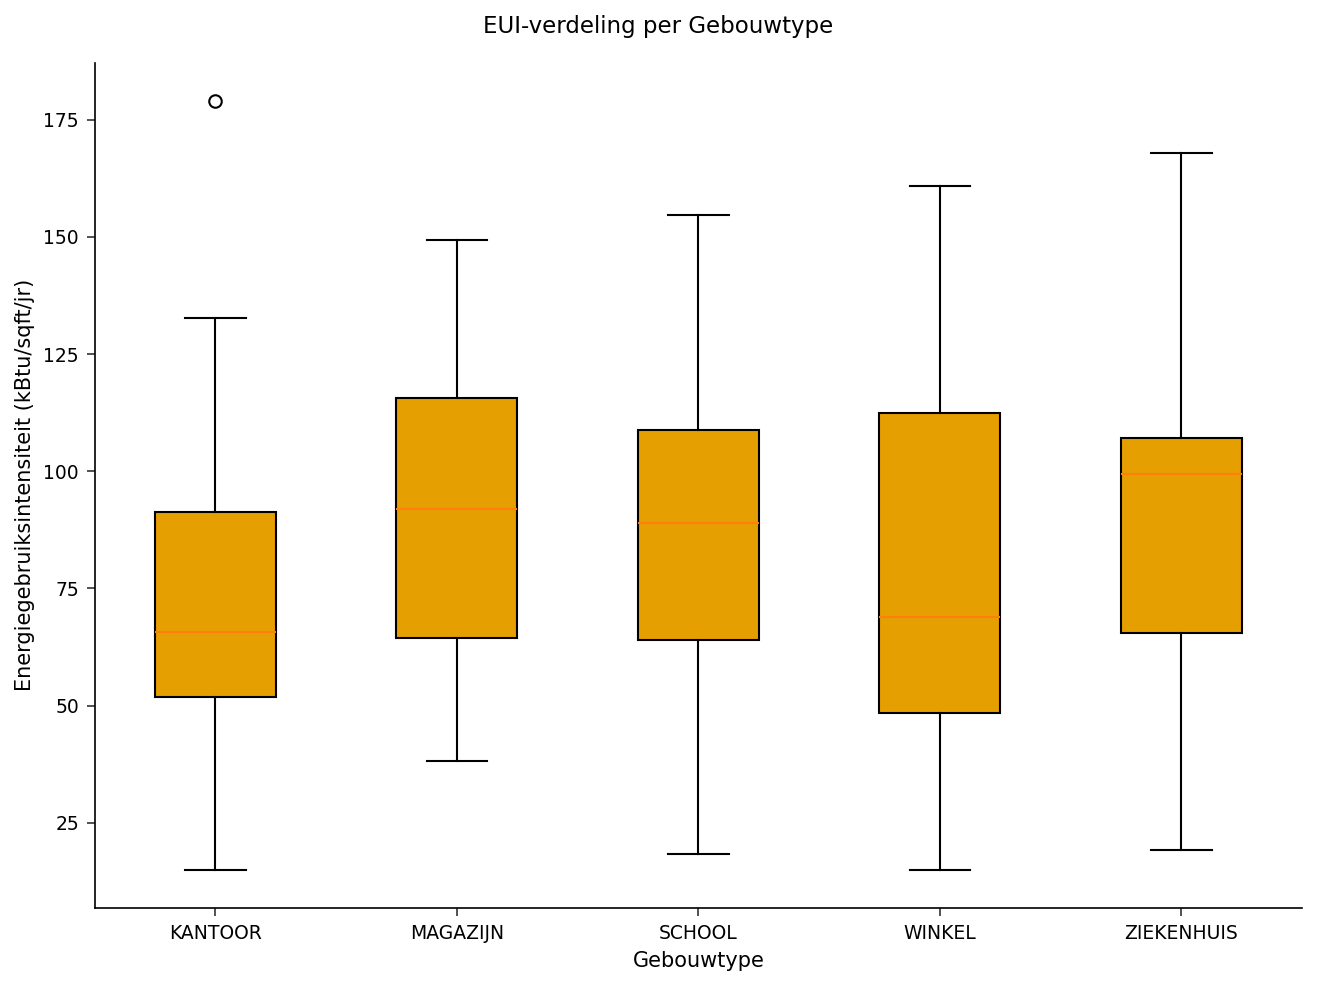

In [3]:
/* --------------------------------------------------------
   EUI-verdeling per gebouwtype
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS label="Gebouwtype";
    YAXIS label="Energiegebruiksintensiteit (kBtu/sqft/jr)";
    TITEL "EUI-verdeling per Gebouwtype";
UITVOEREN;


---

In [4]:
/* --------------------------------------------------------
   Standaardiseer efficiëntiematen
   -------------------------------------------------------- */
PROCEDURE STANDARD GEGEVENS=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
UITVOEREN;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K-means clustering: k=3 met REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURE FASTCLUS GEGEVENS=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Gebouwefficiëntieclustering: k=3 REPLACE=FULL";
UITVOEREN;


                                              Energiematen per Gebouwtype                                               


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K-means clustering: k=4 met REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURE FASTCLUS GEGEVENS=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Gebouwefficiëntieclustering: k=4 REPLACE=FULL";
UITVOEREN;


                                              Energiematen per Gebouwtype                                               


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K-means clustering: k=5 met REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURE FASTCLUS GEGEVENS=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Gebouwefficiëntieclustering: k=5 REPLACE=FULL";
UITVOEREN;


                                              Energiematen per Gebouwtype                                               


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K-means clustering: k=6 met REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURE FASTCLUS GEGEVENS=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Gebouwefficiëntieclustering: k=6 REPLACE=FULL";
UITVOEREN;


                                              Energiematen per Gebouwtype                                               


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Vergelijk clusterkwaliteit over k=3-6
   Bereken within-cluster R-kwadraat en minimale clustergrootte
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCEDURE FREQUENTIES GEGEVENS=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (HERNOEMEN=(count=n_buildings));
UITVOEREN;

PROCEDURE SQL NOPRINT;
    SELECTEREN MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);


                                              Energiematen per Gebouwtype                                               

                                              Energiematen per Gebouwtype                                               

                                              Energiematen per Gebouwtype                                               

                                              Energiematen per Gebouwtype                                               




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                         Gebouwefficiëntieniveauprofielen (k=4)                                         

                                                  The MEANS Procedure

                                    Analysis Variable : eui Energiegebruiksintensiteit (kBtu/sqft/jr)

                                                 N
                                    Cluster    Obs             Mean         Std Dev
                                    -----------------------------------------------
                                    1           23       63.7782609      31.5423086
                                    2           17      122.5941176      36.0679995
                                    3           26       94.0076923      30.8825378
                                    4           34       72.3911765      31.7411154
                                    -----------------------------------------------

                                      Analysis Variable : hvac_e


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


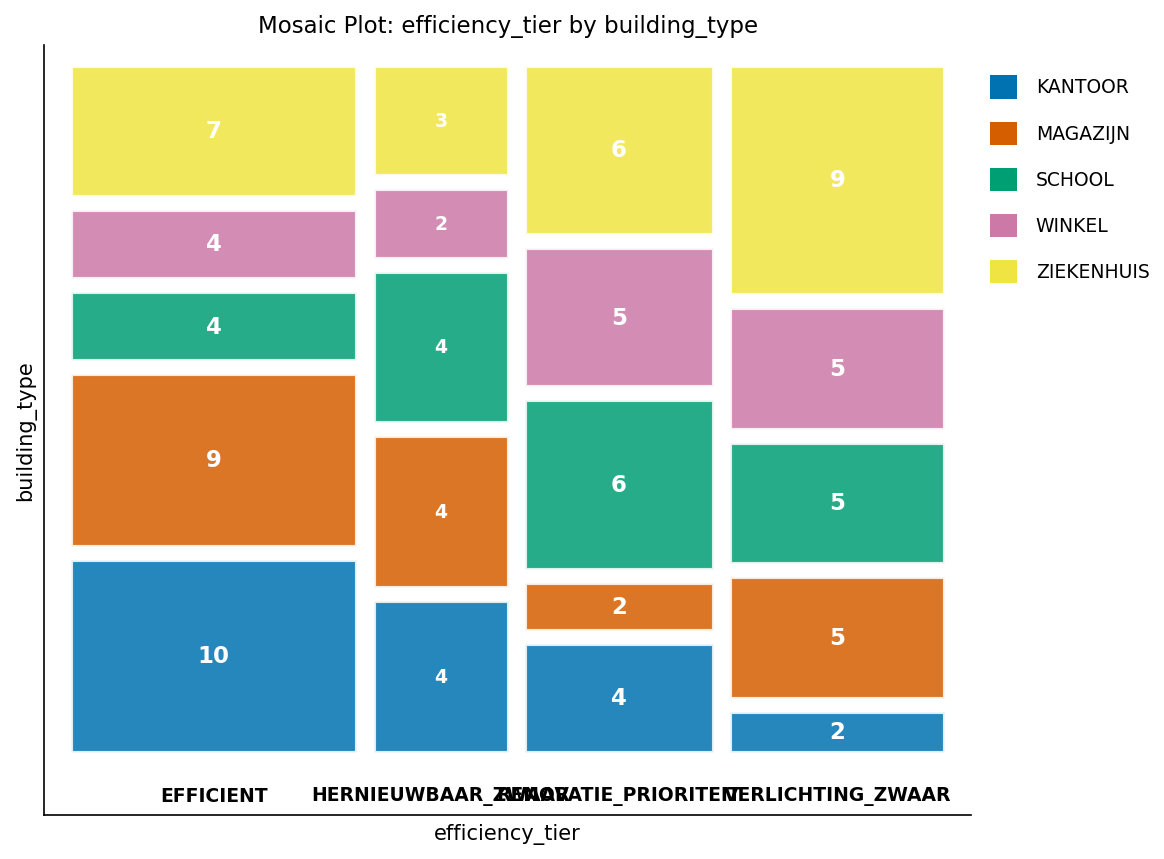

In [10]:
/* --------------------------------------------------------
   Profileer de gekozen k=4-oplossing
   -------------------------------------------------------- */
GEGEVENS work.bldg_profiled;
    SAMENVOEGEN work.building_metrics
          work.bldg_clust4 (BEWAREN=building_id CLUSTER distance);
    VOLGENS building_id;
    label CLUSTER = "Cluster";
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.bldg_profiled mean std;
    KLASSE CLUSTER;
    VARIABELE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    TITEL "Gebouwefficiëntieniveauprofielen (k=4)";
UITVOEREN;

/* Benoem efficiëntieniveaus op basis van de waargenomen k=4-centroïden:
   Cluster 4 = beste HVAC (3.89) bij lage EUI  -> EFFICIENT
   Cluster 2 = hoogste aandeel hernieuwbare energie (28%) maar hoogste EUI -> RENEWABLE_HEAVY
   Cluster 3 = hoogste verlichtingslast, zwakke HVAC, gemiddelde EUI -> LIGHTING_HEAVY
   Cluster 1 = lage EUI maar zwakste HVAC + dunste omhulsel -> RETROFIT_PRIORITY */
GEGEVENS work.bldg_tiered;
    INSTELLEN work.bldg_profiled;
    LENGTE efficiency_tier $24;
    label efficiency_tier = "Efficiëntieniveau";
    ALS CLUSTER = 4 DAN efficiency_tier = 'EFFICIENT';
    ANDERS ALS CLUSTER = 2 DAN efficiency_tier = 'HERNIEUWBAAR_ZWAAR';
    ANDERS ALS CLUSTER = 3 DAN efficiency_tier = 'VERLICHTING_ZWAAR';
    ANDERS ALS CLUSTER = 1 DAN efficiency_tier = 'RENOVATIE_PRIORITEIT';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    TITEL "Efficiëntieniveau per Gebouwtype";
UITVOEREN;


---

### Interpretatie

Met `REPLACE=FULL` convergeerde elke k-waarde probleemloos. Over de vier oplossingen heen steeg de totale R-kwadraat monotoon met k — 0,305 (k=3), 0,410 (k=4), 0,459 (k=5), 0,515 (k=6) — terwijl de pseudo-F-statistiek piekte bij **k=4 (22,23)** en daarna daalde (20,13 bij k=5, 19,93 bij k=6). In combinatie met een minimale clustergrootte van 17 gebouwen bij k=4 (tegenover 13 bij k=5 en 10 bij k=6), biedt de **k=4-oplossing** de beste balans tussen scheiding en stabiliteit van de niveaus, en wordt deze hieronder geprofileerd.

De vier k=4-clusters komen overeen met duidelijk onderscheiden efficiëntieprofielen (gemiddelden uit het PROC MEANS-profiel hierboven):

- **Efficiënt (Cluster 4, n=34):** de best uitgeruste groep — hoogste HVAC-efficiëntie (COP 3,89) bij een lage tot gematigde EUI van 72,4 kBtu/sqft/jr, met een adequaat omhulsel (R 18,8) en een bescheiden aandeel hernieuwbare energie (11,0%).
- **Veel hernieuwbare energie (Cluster 2, n=17):** de hoogste absolute verbruikers (EUI 122,6) maar ook veruit het hoogste aandeel hernieuwbare energie (28,2%), met een gemiddelde HVAC (COP 3,42). Hoge output gecombineerd met opwekking ter plaatse.
- **Veel verlichting (Cluster 3, n=26):** gemiddelde EUI (94,0), gedreven door de hoogste verlichtingsvermogendichtheid (1,35 W/sqft) en de op één na zwakste HVAC (COP 2,42), ondanks het dikste omhulsel (R 19,6).
- **Renovatieprioriteit (Cluster 1, n=23):** lage EUI op papier (63,8) maar de zwakste HVAC (COP 2,28) en het dunste omhulsel (R 12,5) — gebouwen die klein of licht gebruikt zijn maar toch slecht uitgerust, de duidelijkste kandidaten voor omhulsel- en HVAC-renovaties.

De kruistabel van niveau per gebouwtype toont dat kantoren (10) en magazijnen (9) het efficiënte niveau domineren, terwijl ziekenhuizen zich concentreren in het niveau met veel verlichting (9 van de 26). Het niveau renovatieprioriteit is verspreid over de types, met ziekenhuizen en scholen voorop (elk 6 van de 23). Voor het ontwerpen van programma's zijn de 23 gebouwen met renovatieprioriteit en de 26 gebouwen met veel verlichting de voor de hand liggende doelgroepen voor respectievelijk HVAC- en verlichtingsstimulansen, terwijl de 17 gebouwen met veel hernieuwbare energie — die al ter plaatse opwekken — beter geschikt zijn voor vraagreductie dan voor verdere opwekkingssubsidies.

---

In [11]:
/* --------------------------------------------------------
   Exporteer gebouwefficiëntieniveaus en centroïdeprofielen
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>